<a href="https://colab.research.google.com/github/nhjung-phd/TimeSeriesAnalysis/blob/main/notebooks/25_cnn_forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CNN 기반 시계열 예측 (TSLA)

- **실습 1:** 날짜 하나만 입력하는 `Conv1D(kernel_size=1)`의 한계 확인 (순차 패턴 학습 아님)
- **실습 2:** 과거 10거래일의 종가로 다음 거래일 종가 예측 (`Conv1D(kernel_size=2)`)
- **실습 3:** KerasTuner로 CNN 구조 선정, 독립 테스트구간에서 최종 성능 평가

**공통 원칙:** 시간순 Train 60% / Validation 20% / Test 20%; 정규화는 Train에만 `fit`; 모델 선택은 Validation에서 수행. `Naïve = 직전 종가`와 같은 테스트 날짜에서 비교. 각 셀은 독립 실행 가능하도록 구성했습니다.

**유의:** 2022-01-01~2024-01-01 (종료일 미포함)은 고정된 역사적 데이터 기간이지 '최근 2년'이 아닙니다. 그래프는 흰색 배경/영문 레이블을 사용합니다.


## 1. CNN의 한계 사례: 날짜만으로 종가 근사

`Day` 1개를 길이 1의 시퀀스로 넣는 CNN은 과거 종가들의 시간적 배열을 학습하지 않습니다. **교육적 비교용**으로만 유지합니다. 시험기간 정답은 학습·조기종료에 사용하지 않습니다.


                MAE     RMSE      R2
CNN Train   58.5231  70.8361 -0.2089
CNN Test    18.9704  21.7723 -0.5613
Naive Test   5.2946   7.1104  0.8335


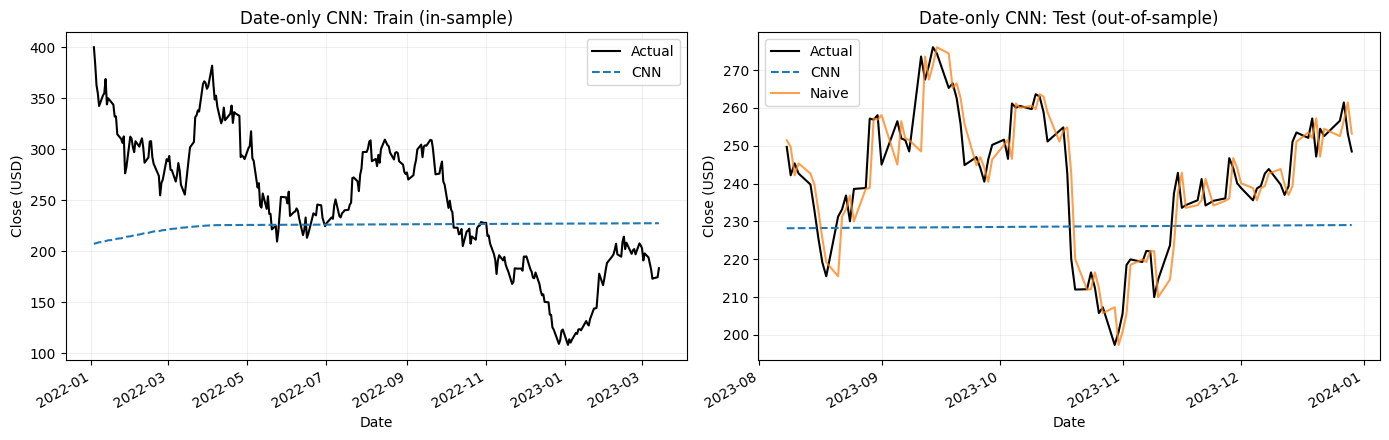

Interpretation: date-only CNN is an extrapolation example, not a temporal CNN benchmark.


In [1]:
# 실습 1: 날짜만 입력하는 CNN (Conv1D(kernel_size=1)) — 교육용 한계 사례
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Conv1D, Flatten, Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

np.random.seed(42)
tf.keras.utils.set_random_seed(42)
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'

# 1. 과거 TSLA 데이터: 실제 종가 자동 조정 (분할 등의 영향 반영)
df = yf.download('TSLA', start='2022-01-01', end='2024-01-01', auto_adjust=True, progress=False)
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)
df = df[['Close']].dropna().reset_index()
if len(df) < 80:
    raise ValueError('TSLA 관측치가 부족합니다. 다운로드 및 날짜를 확인하세요.')
df['Day'] = np.arange(len(df), dtype=float)

# 2. 시간순 분리. 검증/테스트는 미래에 해당하는 뒤쪽 구간입니다.
n = len(df); a = int(n * .6); b = int(n * .8)
X_raw = df[['Day']].to_numpy(); y_raw = df[['Close']].to_numpy()
scaler_X = MinMaxScaler().fit(X_raw[:a])
scaler_y = MinMaxScaler().fit(y_raw[:a])
X_all = scaler_X.transform(X_raw).reshape(-1, 1, 1)
y_all = scaler_y.transform(y_raw)
X_train, X_val, X_test = X_all[:a], X_all[a:b], X_all[b:]
y_train, y_val, y_test = y_all[:a], y_all[a:b], y_all[b:]

# 3. kernel_size=1로는 인접 거래일 종가의 패턴을 학습할 수 없습니다.
model = Sequential([Input(shape=(1,1)), Conv1D(64, 1, activation='relu'),
                    Flatten(), Dense(50, activation='relu'), Dense(1)])
model.compile(optimizer='adam', loss='mse')
history = model.fit(X_train, y_train, validation_data=(X_val, y_val),
                    epochs=100, batch_size=16, shuffle=False,
                    callbacks=[EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True)],
                    verbose=0)

# 4. 테스트는 모델/에포크 선택에 사용하지 않고 최종 한 번만 평가합니다.
pred_train = scaler_y.inverse_transform(model.predict(X_train, verbose=0)).ravel()
pred_test = scaler_y.inverse_transform(model.predict(X_test, verbose=0)).ravel()
actual_train = y_raw[:a, 0]; actual_test = y_raw[b:, 0]
naive_test = y_raw[b-1:-1, 0]  # 같은 테스트 날짜의 직전 종가

def metrics(actual, pred):
    return [mean_absolute_error(actual, pred), np.sqrt(mean_squared_error(actual, pred)),
            r2_score(actual, pred)]
result = pd.DataFrame([metrics(actual_train, pred_train), metrics(actual_test, pred_test),
                       metrics(actual_test, naive_test)],
                      columns=['MAE', 'RMSE', 'R2'], index=['CNN Train', 'CNN Test', 'Naive Test'])
print(result.round(4).to_string())

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
ax[0].plot(df['Date'].iloc[:a], actual_train, label='Actual', color='black')
ax[0].plot(df['Date'].iloc[:a], pred_train, label='CNN', linestyle='--')
ax[0].set_title('Date-only CNN: Train (in-sample)')
ax[1].plot(df['Date'].iloc[b:], actual_test, label='Actual', color='black')
ax[1].plot(df['Date'].iloc[b:], pred_test, label='CNN', linestyle='--')
ax[1].plot(df['Date'].iloc[b:], naive_test, label='Naive', alpha=.75)
ax[1].set_title('Date-only CNN: Test (out-of-sample)')
for axis in ax:
    axis.set_xlabel('Date'); axis.set_ylabel('Close (USD)'); axis.legend(); axis.grid(alpha=.2)
fig.autofmt_xdate(); plt.tight_layout(); plt.show()
print('Interpretation: date-only CNN is an extrapolation example, not a temporal CNN benchmark.')


## 2. Sliding Window CNN: 과거 10거래일로 다음 거래일 종가 예측

각 입력 `X[t]`는 과거 10거래일 종가이고 정답 `y[t]`는 바로 다음 거래일 종가입니다. `Conv1D(kernel_size=2)`는 인접 두 거래일의 국소적 패턴을 학습할 수 있습니다.

- 원시 종가의 처음 60%에 대해서만 `MinMaxScaler.fit()` 수행
- 정답의 날짜를 기준으로 Train / Validation / Test 분리
- 검증기간에서 조기종료, 테스트는 최종 예측만 사용
- Naïve 기준선과 MAE·RMSE·R² 비교


                MAE     RMSE      R2
CNN Train   10.1105  13.0651  0.9554
CNN Test     9.4881  11.5319  0.5620
Naive Test   5.2946   7.1104  0.8335


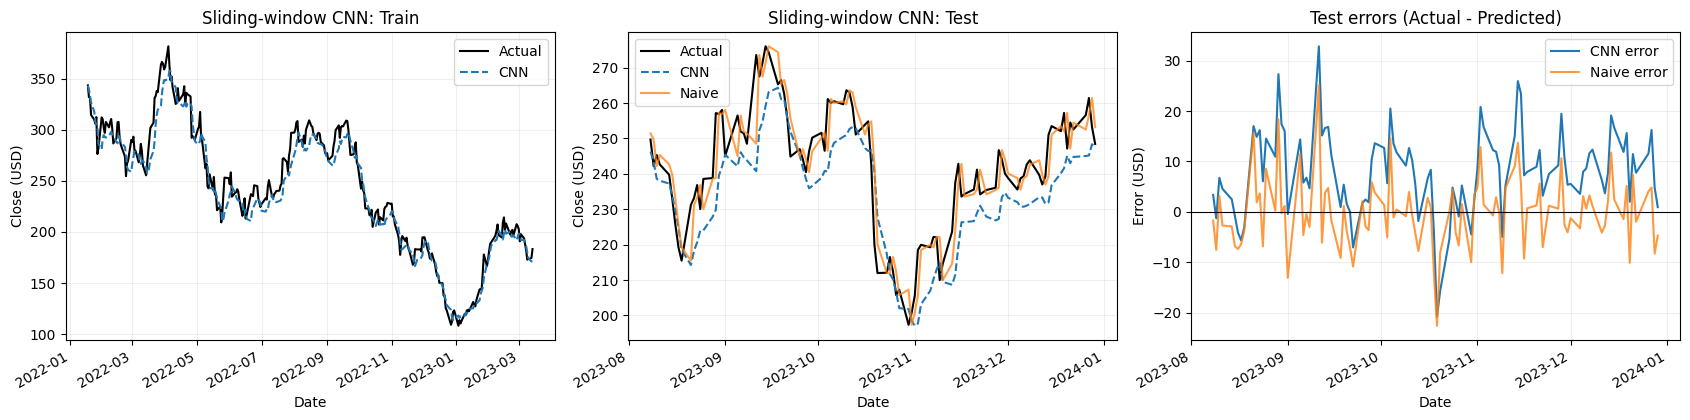

Note: forecast trajectories can overlap; assess test MAE/RMSE and error curves.


In [2]:
# 실습 2: 과거 10일 종가를 이용하는 CNN — 다음 거래일 예측
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Conv1D, Flatten, Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

np.random.seed(42); tf.keras.utils.set_random_seed(42)
plt.rcParams['figure.facecolor'] = 'white'; plt.rcParams['axes.facecolor'] = 'white'
df = yf.download('TSLA', start='2022-01-01', end='2024-01-01', auto_adjust=True, progress=False)
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)
df = df[['Close']].dropna().reset_index()
close = df['Close'].to_numpy(dtype=float).reshape(-1, 1)
window_size = 10
if len(close) <= window_size + 60: raise ValueError('시계열 길이가 너무 짧습니다.')
a, b = int(len(close)*.6), int(len(close)*.8)
scaler = MinMaxScaler().fit(close[:a])  # 중요: 미래 구간으로 fit 하지 않습니다.
scaled_close = scaler.transform(close)

def create_sliding_window_data(data, window_size):
    # X는 [t-window_size, ..., t-1]이고 y는 t 시점 종가입니다.
    X, y = [], []
    for t in range(window_size, len(data)):
        X.append(data[t-window_size:t])
        y.append(data[t])
    return np.asarray(X), np.asarray(y)

X, y = create_sliding_window_data(scaled_close, window_size)
target_idx = np.arange(window_size, len(close))
train_mask = target_idx < a
val_mask = (target_idx >= a) & (target_idx < b)
test_mask = target_idx >= b
X_train, y_train = X[train_mask], y[train_mask]
X_val, y_val = X[val_mask], y[val_mask]
X_test, y_test = X[test_mask], y[test_mask]

model = Sequential([Input(shape=(window_size, 1)), Conv1D(64, 2, activation='relu'),
                    Flatten(), Dense(50, activation='relu'), Dense(1)])
model.compile(optimizer='adam', loss='mse')
history = model.fit(X_train, y_train, validation_data=(X_val, y_val),
                    epochs=100, batch_size=16, shuffle=False, verbose=0,
                    callbacks=[EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True)])

actual_train = scaler.inverse_transform(y_train).ravel()
actual_test = scaler.inverse_transform(y_test).ravel()
pred_train = scaler.inverse_transform(model.predict(X_train, verbose=0)).ravel()
pred_test = scaler.inverse_transform(model.predict(X_test, verbose=0)).ravel()
naive_test = close[target_idx[test_mask]-1, 0]  # 테스트 정답 날짜 바로 전 거래일 종가

def score(y_true, y_pred):
    return [mean_absolute_error(y_true, y_pred), np.sqrt(mean_squared_error(y_true, y_pred)),
            r2_score(y_true, y_pred)]
report = pd.DataFrame([score(actual_train, pred_train), score(actual_test, pred_test),
                       score(actual_test, naive_test)],
                      index=['CNN Train','CNN Test','Naive Test'], columns=['MAE','RMSE','R2'])
print(report.round(4).to_string())

train_dates = df['Date'].iloc[target_idx[train_mask]]
test_dates = df['Date'].iloc[target_idx[test_mask]]
fig, ax = plt.subplots(1, 3, figsize=(17, 4.3))
ax[0].plot(train_dates, actual_train, color='black', label='Actual')
ax[0].plot(train_dates, pred_train, '--', label='CNN'); ax[0].set_title('Sliding-window CNN: Train')
ax[1].plot(test_dates, actual_test, color='black', label='Actual')
ax[1].plot(test_dates, pred_test, '--', label='CNN')
ax[1].plot(test_dates, naive_test, label='Naive', alpha=.75)
ax[1].set_title('Sliding-window CNN: Test')
ax[2].plot(test_dates, actual_test - pred_test, label='CNN error')
ax[2].plot(test_dates, actual_test - naive_test, label='Naive error', alpha=.8)
ax[2].axhline(0, color='black', linewidth=.8); ax[2].set_title('Test errors (Actual - Predicted)')
for axis in ax:
    axis.set_xlabel('Date'); axis.grid(alpha=.2); axis.legend()
ax[0].set_ylabel('Close (USD)'); ax[1].set_ylabel('Close (USD)'); ax[2].set_ylabel('Error (USD)')
fig.autofmt_xdate(); plt.tight_layout(); plt.show()
print('Note: forecast trajectories can overlap; assess test MAE/RMSE and error curves.')


## 3. KerasTuner를 이용한 CNN 하이퍼파라미터 탐색

필터 수, 커널 크기, 활성화 함수, Dense 크기, 학습률을 **Validation Loss**로 선택합니다. 검색과 Early Stopping에 Test를 사용하지 않습니다.

**주의:** 커널 크기는 `window_size=10`보다 작아야 합니다. 실습 시간을 줄이려면 `max_trials`, `executions_per_trial`을 낮출 수 있습니다.


In [3]:
# Colab에서 KerasTuner가 없다면 설치합니다. 이미 설치된 경우에도 실행할 수 있습니다.
%pip -q install keras-tuner


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 9.4 MB/s eta 0:00:00


Selected hyperparameters (validation only): {'filters': 128, 'kernel_size': 2, 'activation': 'tanh', 'dense_units': 32, 'learning_rate': 0.001}
                     MAE     RMSE      R2
Tuned CNN Train  10.0651  12.7459  0.9575
Tuned CNN Test    7.8895  10.0564  0.6669
Naive Test        5.2946   7.1104  0.8335


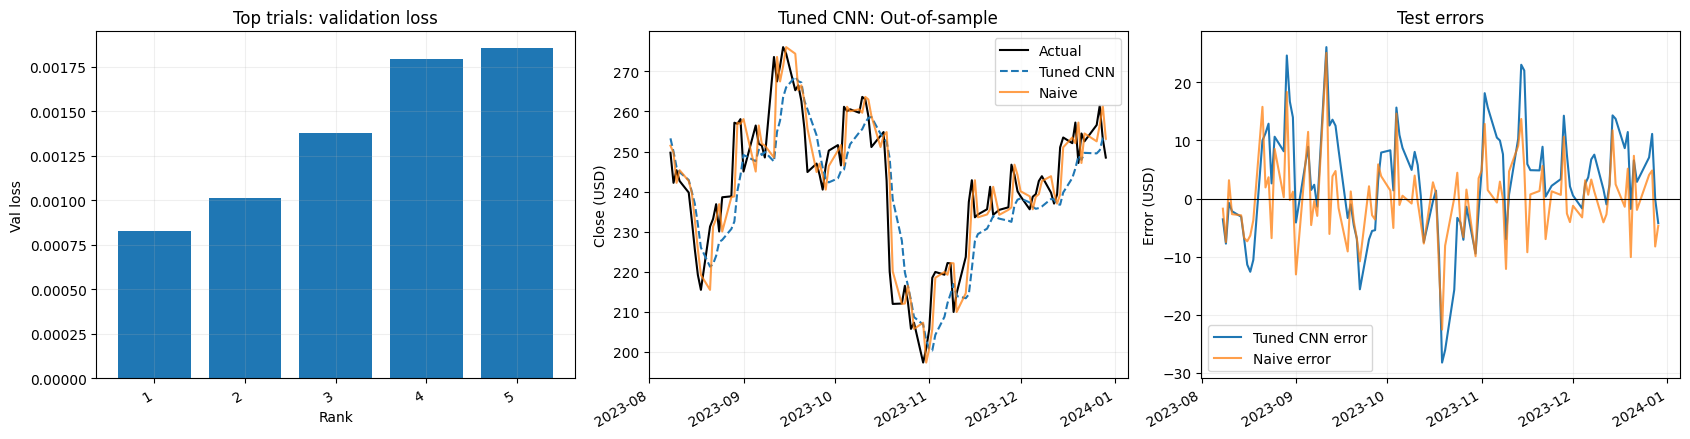

Interpretation: improvements require lower out-of-sample error than Naive.


In [4]:
# 실습 3: CNN 하이퍼파라미터 튜닝 — 테스트 누수 없는 시계열 외표본 평가
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import tensorflow as tf
import keras_tuner as kt
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Conv1D, Flatten, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

np.random.seed(42); tf.keras.utils.set_random_seed(42)
plt.rcParams['figure.facecolor'] = 'white'; plt.rcParams['axes.facecolor'] = 'white'
# 고정된 역사적 기간. 최근 데이터로 바꾸려면 세 실습의 기간을 모두 동일하게 수정하세요.
df = yf.download('TSLA', start='2022-01-01', end='2024-01-01', auto_adjust=True, progress=False)
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)
df = df[['Close']].dropna().reset_index()
close = df['Close'].to_numpy(dtype=float).reshape(-1,1)
window_size = 10
if len(close) <= window_size+60: raise ValueError('관측치가 부족합니다.')
a, b = int(len(close)*.6), int(len(close)*.8)
scaler = MinMaxScaler().fit(close[:a])  # Train 외 값은 scaler 추정에 사용하지 않습니다.
scaled_close = scaler.transform(close)

def create_sliding_window_data(data, window_size):
    X, y = [], []
    for t in range(window_size, len(data)):
        X.append(data[t-window_size:t]); y.append(data[t])
    return np.asarray(X), np.asarray(y)

X, y = create_sliding_window_data(scaled_close, window_size)
target_idx = np.arange(window_size,len(close))
train_mask = target_idx<a
val_mask = (target_idx>=a)&(target_idx<b)
test_mask = target_idx>=b
X_train,y_train = X[train_mask],y[train_mask]
X_val,y_val = X[val_mask],y[val_mask]
X_test,y_test = X[test_mask],y[test_mask]

# KerasTuner는 검증 데이터의 loss를 기준으로 모델 구조와 학습률을 선택합니다.
def build_model(hp):
    m=Sequential([Input(shape=(window_size,1)),
        Conv1D(filters=hp.Int('filters',32,128,step=32),
               kernel_size=hp.Int('kernel_size',2,5),
               activation=hp.Choice('activation',['relu','tanh'])),
        Flatten(),
        Dense(hp.Int('dense_units',16,128,step=16),activation='relu'),
        Dense(1)])
    m.compile(optimizer=Adam(learning_rate=hp.Choice('learning_rate',[.001,.0005,.0001])),loss='mse')
    return m

tuner = kt.RandomSearch(build_model, objective='val_loss', max_trials=10,
                        executions_per_trial=1, overwrite=True,
                        directory='hyperparameter_tuning', project_name='Tesla_CNN_Tuning')
stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
tuner.search(X_train,y_train,epochs=50,batch_size=16,shuffle=False,
             validation_data=(X_val,y_val), callbacks=[stop],verbose=0)
best_hps = tuner.get_best_hyperparameters(1)[0]
print('Selected hyperparameters (validation only):',best_hps.values)

# 선정된 모형을 다시 초기화하여 Train으로 재학습, Validation으로 조기종료합니다.
best_model = tuner.hypermodel.build(best_hps)
history = best_model.fit(X_train,y_train,epochs=100,batch_size=16,shuffle=False,
                         validation_data=(X_val,y_val),
                         callbacks=[EarlyStopping(monitor='val_loss',patience=12,restore_best_weights=True)],
                         verbose=0)
actual_train = scaler.inverse_transform(y_train).ravel()
actual_test = scaler.inverse_transform(y_test).ravel()
pred_train = scaler.inverse_transform(best_model.predict(X_train,verbose=0)).ravel()
pred_test = scaler.inverse_transform(best_model.predict(X_test,verbose=0)).ravel()
naive_test = close[target_idx[test_mask]-1,0]

def score(y_true,y_pred):
    return [mean_absolute_error(y_true,y_pred),np.sqrt(mean_squared_error(y_true,y_pred)),r2_score(y_true,y_pred)]
report=pd.DataFrame([score(actual_train,pred_train),score(actual_test,pred_test),
                     score(actual_test,naive_test)],
                    columns=['MAE','RMSE','R2'],index=['Tuned CNN Train','Tuned CNN Test','Naive Test'])
print(report.round(4).to_string())

best_trials=tuner.oracle.get_best_trials(num_trials=5)
fig,ax=plt.subplots(1,3,figsize=(17,4.5))
ax[0].bar(np.arange(1,len(best_trials)+1),[t.metrics.get_best_value('val_loss') for t in best_trials])
ax[0].set_title('Top trials: validation loss');ax[0].set_xlabel('Rank');ax[0].set_ylabel('Val loss')
test_dates=df['Date'].iloc[target_idx[test_mask]]
ax[1].plot(test_dates,actual_test,label='Actual',color='black')
ax[1].plot(test_dates,pred_test,label='Tuned CNN',linestyle='--')
ax[1].plot(test_dates,naive_test,label='Naive',alpha=.75)
ax[1].set_title('Tuned CNN: Out-of-sample');ax[1].set_ylabel('Close (USD)')
ax[2].plot(test_dates,actual_test-pred_test,label='Tuned CNN error')
ax[2].plot(test_dates,actual_test-naive_test,label='Naive error',alpha=.75)
ax[2].axhline(0,color='black',linewidth=.8);ax[2].set_title('Test errors');ax[2].set_ylabel('Error (USD)')
for axis in ax: axis.grid(alpha=.2);axis.legend() if axis!=ax[0] else None
fig.autofmt_xdate();plt.tight_layout();plt.show()
print('Interpretation: improvements require lower out-of-sample error than Naive.')


### 실습 결과 해석과 주의사항

1. **첫 번째 CNN은 교육용 한계 사례:** `kernel_size=1`에 날짜 하나만 입력하므로 시계열의 국소 패턴을 학습하지 않습니다.
2. **두 번째·세 번째 CNN은 1-step ahead:** 과거 10거래일 종가로 다음 거래일 종가를 예측합니다. 테스트 윈도우에는 직전 테스트 날짜의 **관측 완료된 종가**가 들어갈 수 있습니다. 이는 매 거래일 예측을 갱신하는 상황을 가정합니다.
3. **Full-sample 스케일링 및 Test 기반 튜닝 금지:** 정규화는 Train만으로 적합하고 검증에는 Validation만 사용합니다.
4. **Naïve 비교 필수:** 주가 경로 예측선이 겹칠 수 있으므로 MAE·RMSE와 `Actual - Predicted` 오차 그래프를 함께 봅니다.
5. **예측 성능은 보장되지 않음:** 더 복잡한 CNN이 반드시 Naïve, ANN, RNN, LSTM, GRU보다 우수하지 않습니다.
6. **실험 조건:** 고정된 2022~2023년 TSLA 데이터, 조정 종가(`auto_adjust=True`); 단일 종목·단일 테스트 구간 결과를 일반화하지 않습니다. 실제 성능은 Colab 실행 후 확인하세요.

**토론:** 윈도우 길이(10→20), 예측 지평(1→5일), 다른 평가기간에서 성능 순위가 유지될까요? 변경사항은 Validation으로 선택하고 최종 Test를 반복 사용하여 선택하지 마세요.
